In [1]:
from google.colab import files

uploaded = files.upload()

Saving Cucumber Datasets.v2i.openai.zip to Cucumber Datasets.v2i.openai.zip


In [2]:
import os
import zipfile

zip_path = "/content/Cucumber Datasets.v2i.openai.zip"
extract_path = "/content/cucumber_dataset"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")
print(os.listdir(extract_path))

Dataset extracted successfully!
['_annotations.valid.jsonl', '_annotations.test.jsonl', 'README.dataset.txt', '_annotations.train.jsonl', 'README.roboflow.txt']


In [3]:
!pip install -q tensorflow pandas scikit-learn

In [5]:
import json
import pandas as pd

def load_jsonl(file_path):
    data = []

    with open(file_path, "r") as file:
        for line in file:
            item = json.loads(line)

            image_url = None
            label = None

            for message in item["messages"]:
                if message["role"] == "user" and isinstance(message["content"], list):
                    image_url = message["content"][0]["image_url"]["url"]

                elif message["role"] == "assistant":
                    label = message["content"]

            data.append({
                "image_url": image_url,
                "label": label
            })

    return pd.DataFrame(data)

In [6]:
train_df = load_jsonl("/content/cucumber_dataset/_annotations.train.jsonl")
valid_df = load_jsonl("/content/cucumber_dataset/_annotations.valid.jsonl")
test_df = load_jsonl("/content/cucumber_dataset/_annotations.test.jsonl")

print("Training images:", len(train_df))
print("Validation images:", len(valid_df))
print("Testing images:", len(test_df))

print("\nTraining labels:")
print(train_df["label"].value_counts())

Training images: 589
Validation images: 2
Testing images: 1

Training labels:
label
Good    424
Bad     165
Name: count, dtype: int64


In [7]:
import requests
from PIL import Image
from io import BytesIO
import os
from tqdm import tqdm

In [8]:
base_path = "/content/cucumber_images"

for split in ["train", "valid", "test"]:
    for label in ["Good", "Bad"]:
        os.makedirs(f"{base_path}/{split}/{label}", exist_ok=True)

In [9]:
def download_images(df, split):
    failed = []

    for index, row in tqdm(df.iterrows(), total=len(df)):
        url = row["image_url"]
        label = row["label"].strip()

        try:
            response = requests.get(url, timeout=30)
            response.raise_for_status()

            image = Image.open(BytesIO(response.content)).convert("RGB")

            image_path = f"{base_path}/{split}/{label}/image_{index}.jpg"

            image.save(image_path, "JPEG")

        except Exception as e:
            print(f"Failed to download image {index}: {e}")
            failed.append(index)

    print(f"\nFinished downloading {split}.")
    print("Failed downloads:", len(failed))

In [11]:
download_images(train_df, "train")
download_images(valid_df, "valid")
download_images(test_df, "test")

100%|██████████| 589/589 [00:45<00:00, 12.92it/s]



Finished downloading train.
Failed downloads: 0


100%|██████████| 2/2 [00:00<00:00, 12.50it/s]



Finished downloading valid.
Failed downloads: 0


100%|██████████| 1/1 [00:00<00:00, 10.85it/s]


Finished downloading test.
Failed downloads: 0


In [12]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [13]:
valid_ds = tf.keras.utils.image_dataset_from_directory(
    f"{base_path}/valid",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 2 files belonging to 2 classes.


In [14]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    f"{base_path}/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 1 files belonging to 2 classes.


In [17]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    f"{base_path}/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

print("Classes:", train_ds.class_names)

Found 589 files belonging to 2 classes.
Classes: ['Bad', 'Good']


In [18]:
AUTOTUNE = tf.data.AUTOTUNE

# Store class names before prefetching
class_names_for_plotting = train_ds.class_names

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
valid_ds = valid_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

In [19]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model

In [20]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [21]:
inputs = tf.keras.Input(shape=(224, 224, 3))

x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)

x = base_model(x, training=False)

x = GlobalAveragePooling2D()(x)

x = Dropout(0.3)(x)

outputs = Dense(1, activation="sigmoid")(x)

model = Model(inputs, outputs)

In [22]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [23]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [24]:
EPOCHS = 20

history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=EPOCHS
)

Epoch 1/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.7555 - loss: 0.5336 - val_accuracy: 0.5000 - val_loss: 0.9167
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.9304 - loss: 0.2304 - val_accuracy: 0.5000 - val_loss: 0.7167
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.9694 - loss: 0.1503 - val_accuracy: 0.5000 - val_loss: 0.7928
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.9796 - loss: 0.1043 - val_accuracy: 0.5000 - val_loss: 0.5200
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.9864 - loss: 0.0838 - val_accuracy: 0.5000 - val_loss: 0.5585
Epoch 6/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.9881 - loss: 0.0729 - val_accuracy: 0.5000 - val_loss: 0.4541
Epoch 7/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.9898 - loss: 0.0623 - val_accuracy: 0.5000 - val_loss: 0.4182
Epoch 8/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.9898 - loss: 0.0525 - val_accuracy: 1.0000 - val_loss:

In [25]:
model.save("/content/cucumber_good_bad_classifier.keras")

print("Model saved successfully!")

Model saved successfully!


In [26]:
from google.colab import files

files.download("/content/cucumber_good_bad_classifier.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [27]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 565ms/step - accuracy: 1.0000 - loss: 0.0016
Test Loss: 0.0016032735584303737
Test Accuracy: 1.0


In [28]:
import numpy as np

predictions = model.predict(test_ds)

predicted_labels = (predictions > 0.5).astype(int).flatten()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


In [29]:
true_labels = np.concatenate([
    labels.numpy()
    for images, labels in test_ds
])

In [30]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

In [35]:
cm = confusion_matrix(true_labels, predicted_labels)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[1]]


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [38]:
from google.colab import files

uploaded = files.upload()

Saving images (1).jpg to images (1).jpg


In [39]:
from tensorflow.keras.preprocessing import image
import numpy as np

image_name = list(uploaded.keys())[0]

img = image.load_img(
    image_name,
    target_size=(224, 224)
)

img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)[0][0]

if prediction > 0.5:
    print("Prediction: GOOD CUCUMBER")
    print("Confidence:", round(float(prediction) * 100, 2), "%")
else:
    print("Prediction: BAD CUCUMBER")
    print("Confidence:", round((1 - float(prediction)) * 100, 2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Prediction: GOOD CUCUMBER
Confidence: 99.5 %


Confusion Matrix:
[[1 0]
 [0 0]]


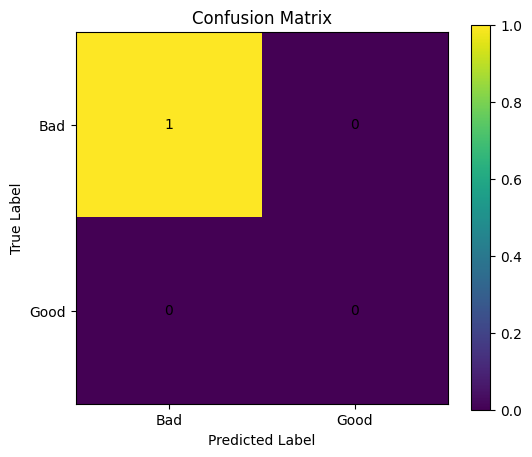

In [43]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Force both classes to appear
cm = confusion_matrix(
    true_labels,
    predicted_labels,
    labels=[0, 1]
)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks([0, 1], ["Bad", "Good"])
plt.yticks([0, 1], ["Bad", "Good"])

for i in range(2):
    for j in range(2):
        plt.text(
            j, i,
            str(cm[i, j]),
            ha="center",
            va="center"
        )

plt.colorbar()
plt.show()

In [44]:
from sklearn.metrics import classification_report

# Force the report to use both classes:
# 0 = Bad
# 1 = Good

print(
    classification_report(
        true_labels,
        predicted_labels,
        labels=[0, 1],
        target_names=["Bad", "Good"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

         Bad       1.00      1.00      1.00         1
        Good       0.00      0.00      0.00         0

    accuracy                           1.00         1
   macro avg       0.50      0.50      0.50         1
weighted avg       1.00      1.00      1.00         1

